In [6]:
import os
from pathlib import Path
from pprint import pprint
import matplotlib.pyplot as plt

from nhandienmonan import run_full_pipeline, load_image, CLASS_NAMES

ROOT = Path(os.getcwd()).resolve()        # Jupyter/
PROJ_ROOT = ROOT.parent                   # DL-DuDoan33MonAnVietNam/

print("ROOT      :", ROOT)
print("PROJ_ROOT :", PROJ_ROOT)

# 1) YOLO DETECTOR – đóng box dĩa/món trên bàn
YOLO_WEIGHTS = ROOT / "Yolo" / "MTL_FOOD_PLATE_01" / "weights" / "best.pt"

# 2) CLASSIFIER EfficientNet 33 món
CLF_WEIGHTS  = ROOT / "runs" / "MTL_TGFOOD" / "checkpoints" / "mtl_effcientnet_b0_best.pt"
#MTL_TGFOOD_INC_20251118_210601
print("YOLO_WEIGHTS:", YOLO_WEIGHTS, os.path.isfile(YOLO_WEIGHTS))
print("CLF_WEIGHTS :", CLF_WEIGHTS,  os.path.isfile(CLF_WEIGHTS))

OUTPUT_BOXES_DIR = ROOT / "YOLO_33" / "images"
OUTPUT_CROPS_DIR = OUTPUT_BOXES_DIR / "crops"

DET_CONF_THRES = 0.1
CLS_CONF_THRES = 0.90

print("Số class trong CLASS_NAMES (json):", len(CLASS_NAMES))


ROOT      : /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter
PROJ_ROOT : /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam
YOLO_WEIGHTS: /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/Yolo/MTL_FOOD_PLATE_01/weights/best.pt True
CLF_WEIGHTS : /media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/runs/MTL_TGFOOD/checkpoints/mtl_effcientnet_b0_best.pt True
Số class trong CLASS_NAMES (json): 33


Ảnh test: test/6.jpg


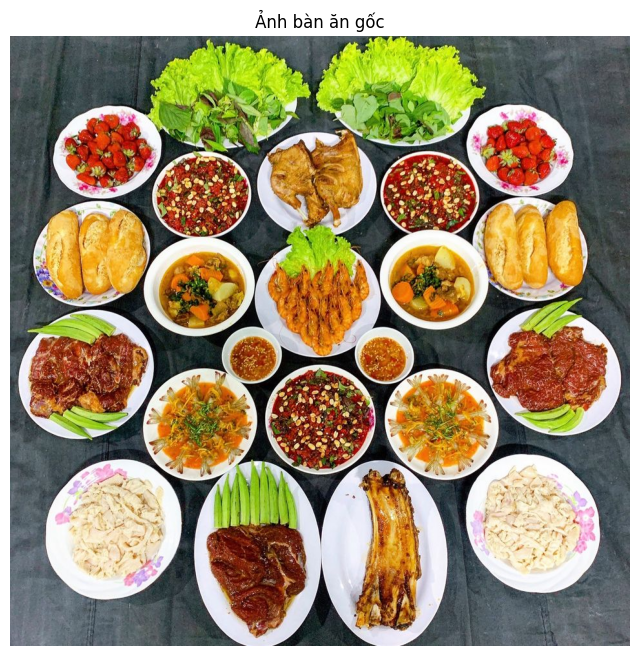

In [7]:
# Ảnh test (anh chỉnh lại tuỳ chỗ lưu)
test_image_path = Path("test/6.jpg")

assert test_image_path.is_file(), f"Không tìm thấy ảnh: {test_image_path}"
print("Ảnh test:", test_image_path)

img = load_image(str(test_image_path))

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Ảnh bàn ăn gốc")
plt.show()


In [8]:
result = run_full_pipeline(
    image_path=str(test_image_path),
    yolo_weights=str(YOLO_WEIGHTS),
    clf_weights=str(CLF_WEIGHTS),
    output_boxes_dir=str(OUTPUT_BOXES_DIR),
    output_crops_dir=str(OUTPUT_CROPS_DIR),
    det_conf_thres=DET_CONF_THRES,
    cls_conf_thres=CLS_CONF_THRES,
    show_unknown=False,   # chỉ vẽ các món >= CLS_CONF_THRES
)

print("Ảnh output (đã vẽ box) lưu tại:")
print(result["boxed_image_path"])

print("\nSố box detect được:", len(result["boxes_xyxy"]))
print("Đếm món theo label (vượt ngưỡng):")
pprint(result["counts"])


➡️  Classifier checkpoint out_dim = 33
⚠️ Missing keys khi load classifier: 0
⚠️ Unexpected keys khi load classifier: 0
   class_names trong ckpt: 33 lớp
Ảnh output (đã vẽ box) lưu tại:
/media/mtl/DATA 6TB/PROJECT AI/DL-DuDoan33MonAnVietNam/Jupyter/YOLO_33/images/6_boxed.jpg

Số box detect được: 22
Đếm món theo label (vượt ngưỡng):
Counter({'banh_tieu': 5,
         'Xoi xeo': 3,
         'Canh chua': 1,
         'Banh trang nuong': 1,
         'Cao lau': 1})


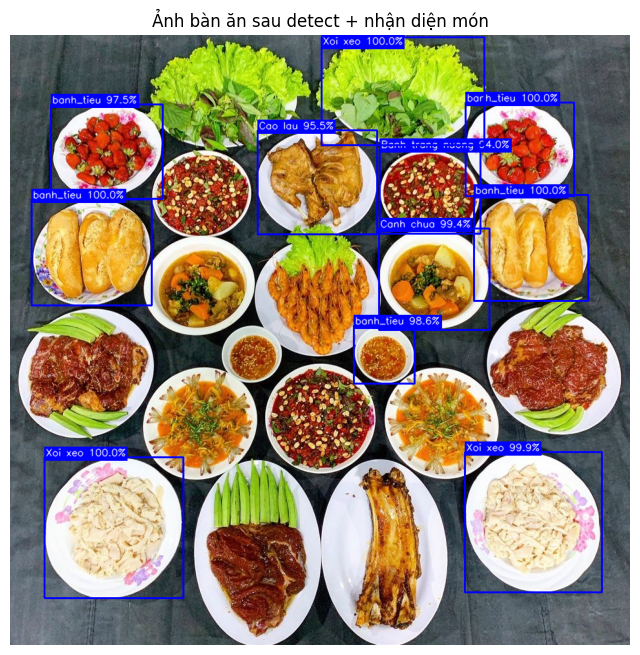

In [9]:
boxed_img = result["boxed_image"]

plt.figure(figsize=(8, 8))
plt.imshow(boxed_img)
plt.axis("off")
plt.title("Ảnh bàn ăn sau detect + nhận diện món")
plt.show()


Tổng số vùng món ăn detect được: 22


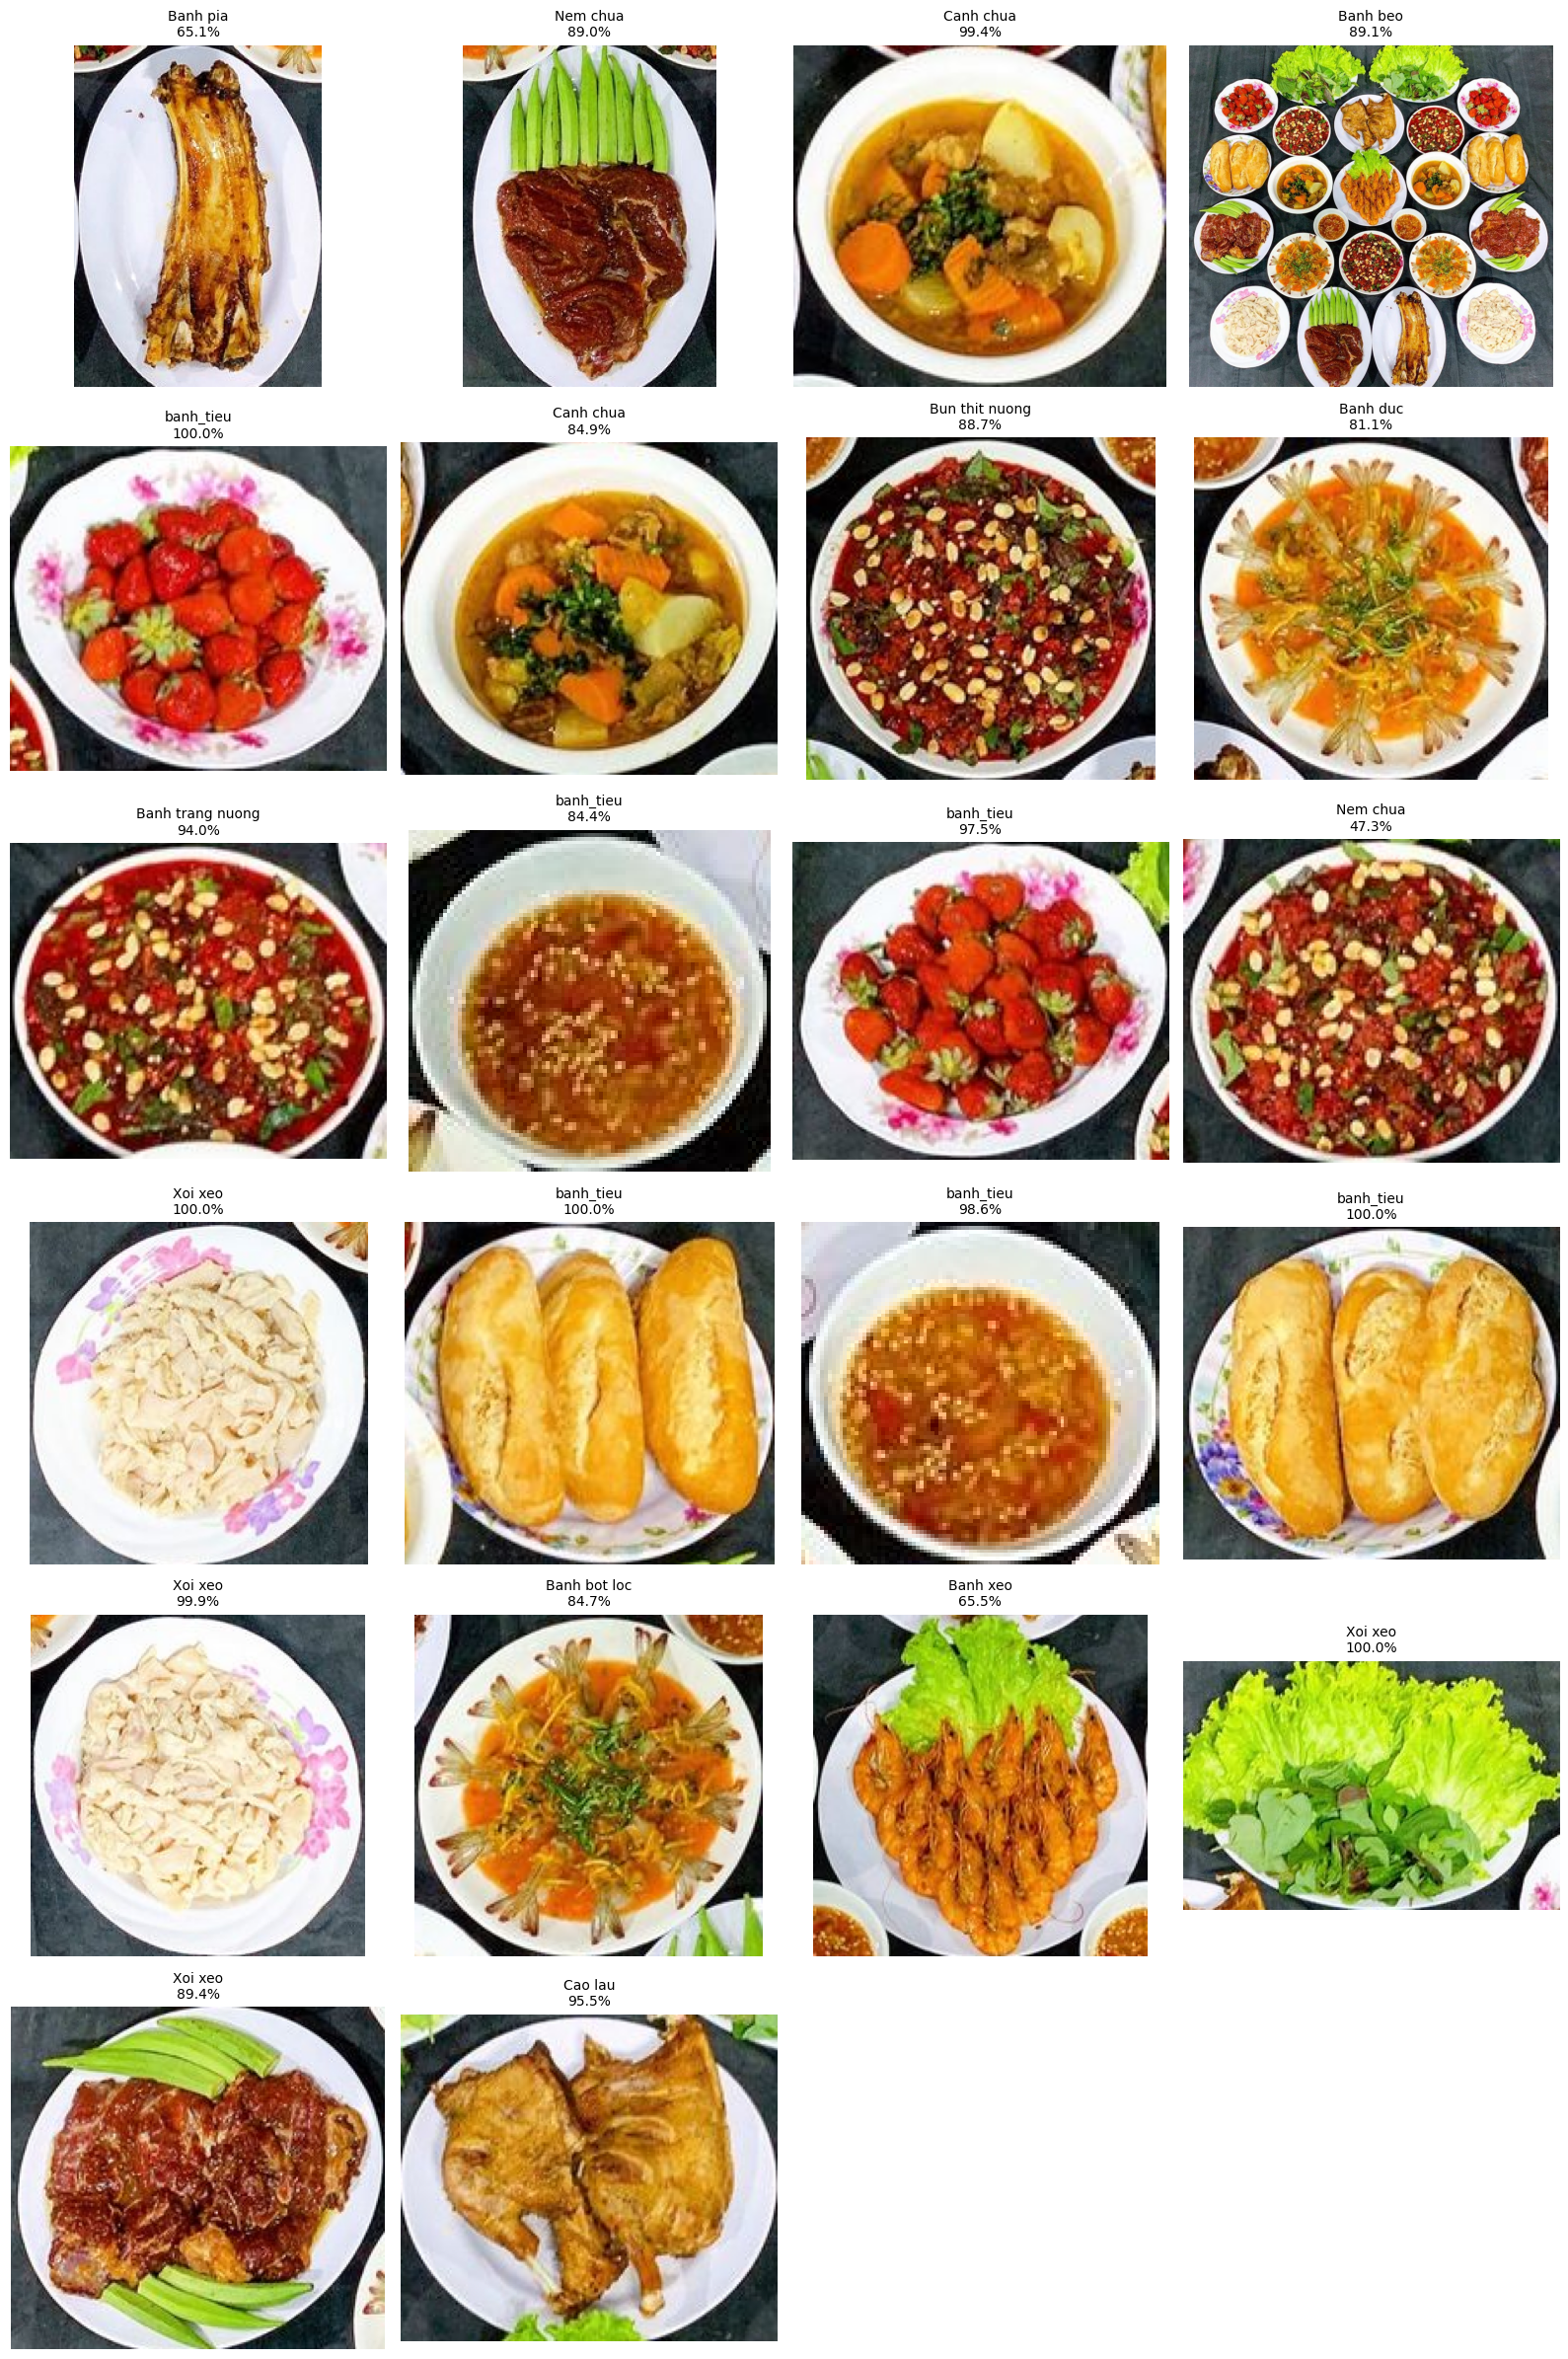

In [10]:
crops = result["crops"]
class_results = result["class_results"]

print(f"Tổng số vùng món ăn detect được: {len(crops)}")

if len(crops) > 0:
    cols = 4
    rows = (len(crops) + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (crop, cls_res) in enumerate(zip(crops, class_results)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(crop)
        label = cls_res["label_name"]
        score = cls_res["score"] * 100
        plt.title(f"{label}\n{score:.1f}%", fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("YOLO không detect được món nào trên ảnh này (thử giảm DET_CONF_THRES).")
